# TASK_7:Get Basic Sales Summary from a Tiny SQLite Database using Python

In [2]:
#importing sqlite3

import sqlite3

# Connect to the database
conn = sqlite3.connect('Sales_data.db')
cursor = conn.cursor()

# Commit and close connection
conn.commit()
conn.close()

# Connect to the database 
conn = sqlite3.connect('Sales_data.db')
cursor = conn.cursor()

# Creating the table with the correct columns
cursor.execute('''
CREATE TABLE IF NOT EXISTS Sales (
    order_number INTEGER,
    quantity_ordered INTEGER,
    product_line TEXT,
    sales REAL,
    order_date TEXT,
    country TEXT
)
''')

# Commit and close connection
conn.commit()
conn.close()

In [3]:
# Connect to the database again
conn = sqlite3.connect('Sales_data.db')
cursor = conn.cursor()

# Sample data
order_data = [
    (10107, 30, "Motorcycles", 2871, "24-02-2018", "USA"),
    (10121, 34, "Trucks and Buses", 2765.9, "07-05-2018", "France"),
    (10134, 41, "Motorcycles", 3884.34, "01-07-2018", "France"),
    (10145, 45, "Classic Cars", 3746.7, "25-08-2018", "USA"),
    (10168, 36, "Motorcycles", 3479.76, "28-10-2018", "USA"),
    (10180, 29, "Motorcycles", 2497.77, "11-11-2018", "France"),
    (10188, 48, "Classic Cars", 5512.32, "18-11-2018", "Norway"),
    (10211, 41, "Motorcycles", 4708.44, "15-01-2019", "France"),
    (10223, 37, "Vintage Cars", 3965.66, "20-02-2019", "Australia"),
    (10237, 23, "Motorcycles", 2333.12, "05-04-2019", "USA"),
    (10251, 28, "Motorcycles", 3188.64, "18-05-2019", "USA"),
    (10263, 34, "Trucks and Buses", 3676.76, "28-06-2019", "USA"),
    (10275, 45, "Classic Cars", 4177.35, "23-07-2019", "France"),
    (10285, 36, "Motorcycles", 4099.68, "27-08-2019", "USA"),
    (10299, 23, "Vintage Cars", 2597.39, "30-09-2019", "Finland"),
    (10309, 41, "Trucks and Buses", 4394.38, "15-10-2019", "Norway"),
    (10318, 46, "Motorcycles", 4358.04, "02-11-2019", "USA"),
    (10329, 42, "Classic Cars", 4396.14, "15-11-2019", "USA"),
    (10341, 41, "Motorcycles", 7737.93, "24-11-2019", "Austria"),
]

# Insert the data
cursor.executemany('''
    INSERT INTO Sales (order_number, quantity_ordered, product_line, sales, order_date, country)
    VALUES (?, ?, ?, ?, ?, ?)
''', order_data)

# Commit and close connection
conn.commit()
conn.close()


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
conn = sqlite3.connect("Sales_data.db")
df= pd.read_sql_query('select * from Sales', conn)
conn.close()
print(df)

    order_number  quantity_ordered      product_line    sales  order_date  \
0          10107                30       Motorcycles  2871.00  24-02-2018   
1          10121                34  Trucks and Buses  2765.90  07-05-2018   
2          10134                41       Motorcycles  3884.34  01-07-2018   
3          10145                45      Classic Cars  3746.70  25-08-2018   
4          10168                36       Motorcycles  3479.76  28-10-2018   
5          10180                29       Motorcycles  2497.77  11-11-2018   
6          10188                48      Classic Cars  5512.32  18-11-2018   
7          10211                41       Motorcycles  4708.44  15-01-2019   
8          10223                37      Vintage Cars  3965.66  20-02-2019   
9          10237                23       Motorcycles  2333.12  05-04-2019   
10         10251                28       Motorcycles  3188.64  18-05-2019   
11         10263                34  Trucks and Buses  3676.76  28-06-2019   

In [6]:
# Connect to the database
conn = sqlite3.connect("sales_data.db")

# SQL Query: Get total quantity and revenue for each product
sql_query = """
SELECT product_line,
       SUM(quantity_ordered) AS total_quantity,
       SUM(quantity_ordered * sales) AS revenue
FROM sales
GROUP BY product_line
"""

df = pd.read_sql_query(sql_query, conn)
conn.close()

print("Sales Summary:\n", df)

Sales Summary:
        product_line  total_quantity     revenue
0      Classic Cars             180   805811.49
1       Motorcycles             351  1444397.80
2  Trucks and Buses             109   399220.02
3      Vintage Cars              60   206469.39


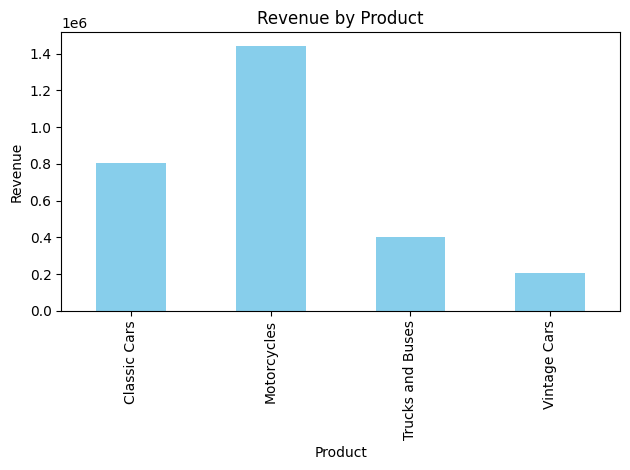

In [7]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("sales_data.db")

# SQL Query: Get total quantity and revenue for each product
sql_query = """
SELECT product_line,
       SUM(quantity_ordered) AS total_quantity,
       SUM(quantity_ordered * sales) AS revenue
FROM sales
GROUP BY product_line
"""

df = pd.read_sql_query(sql_query, conn)
conn.close()

# Plot revenue by product_line
df.plot(kind='bar', x='product_line', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.xlabel("Product" )
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [6]:
plt.savefig("sales_chart.png")

<Figure size 640x480 with 0 Axes>

### Other sql queries

In [8]:
import sqlite3
import pandas as pd

# Connect to the database
conn = sqlite3.connect("Sales_data.db")

# 1. Total Revenue
query1 = "SELECT SUM(sales) AS total_revenue FROM Sales;"
total_revenue = pd.read_sql_query(query1, conn)
print("1. Total Revenue:\n", total_revenue, "\n")

# 2. Total Quantity Sold
query2 = "SELECT SUM(quantity_ordered) AS total_quantity_sold FROM Sales;"
total_quantity = pd.read_sql_query(query2, conn)
print("2. Total Quantity Sold:\n", total_quantity, "\n")

# 3. Total Orders
query3 = "SELECT COUNT(*) AS total_orders FROM Sales;"
total_orders = pd.read_sql_query(query3, conn)
print("3. Total Orders:\n", total_orders, "\n")

# 4. Revenue by Product Line
query4 = """
SELECT product_line, SUM(sales) AS revenue 
FROM Sales 
GROUP BY product_line;
"""
revenue_by_product = pd.read_sql_query(query4, conn)
print("4. Revenue by Product Line:\n", revenue_by_product, "\n")

# 5. Top-Selling Product Line (by revenue)
query5 = """
SELECT product_line, SUM(sales) AS revenue 
FROM Sales 
GROUP BY product_line 
ORDER BY revenue DESC 
LIMIT 1;
"""
top_product_line = pd.read_sql_query(query5, conn)
print("5. Top-Selling Product Line:\n", top_product_line, "\n")

# 6. Sales by Country
query6 = """
SELECT country, SUM(sales) AS revenue 
FROM Sales 
GROUP BY country;
"""
sales_by_country = pd.read_sql_query(query6, conn)
print("6. Sales by Country:\n", sales_by_country, "\n")

conn.close()


1. Total Revenue:
    total_revenue
0       74391.32 

2. Total Quantity Sold:
    total_quantity_sold
0                  700 

3. Total Orders:
    total_orders
0            19 

4. Revenue by Product Line:
        product_line   revenue
0      Classic Cars  17832.51
1       Motorcycles  39158.72
2  Trucks and Buses  10837.04
3      Vintage Cars   6563.05 

5. Top-Selling Product Line:
   product_line   revenue
0  Motorcycles  39158.72 

6. Sales by Country:
      country   revenue
0  Australia   3965.66
1    Austria   7737.93
2    Finland   2597.39
3     France  18033.80
4     Norway   9906.70
5        USA  32149.84 

